In [1]:
# 1. Import the necessary libraries
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore') # Keeps our output clean

# 2. Load the enhanced dataset
df = pd.read_csv('../data/enhanced_hostel_data.csv')

# 3. Apply Hard Constraints: Separate by Gender
# We will build the model for Male students first as an example
male_students = df[df['Gender'] == 'Male'].copy()
female_students = df[df['Gender'] == 'Female'].copy()

print(f"Total Male Students: {len(male_students)}")
print(f"Total Female Students: {len(female_students)}")

# 4. Isolate the personality features for the algorithm
# We drop ID, Gender, and Smoker because K-Means only wants the 1-5 math scores
features_to_cluster = ['Sleep_Schedule', 'Study_Habit', 'Cleanliness', 'Social_Personality', 'Visitor_Frequency']

male_features = male_students[features_to_cluster]

# 5. Scale the data (Standard ML Practice)
scaler = StandardScaler()
male_scaled = scaler.fit_transform(male_features)

print("\nData successfully filtered and scaled. Ready for K-Means!")

Total Male Students: 244
Total Female Students: 256

Data successfully filtered and scaled. Ready for K-Means!


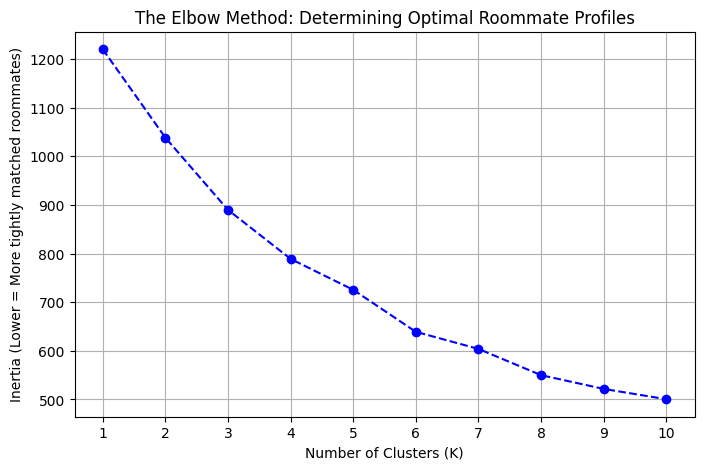

In [2]:
import matplotlib.pyplot as plt

# 1. Calculate Inertia for K values from 1 to 10
# Inertia measures how tightly packed (similar) the students in each cluster are.
inertia = []
k_values = range(1, 11)

for k in k_values:
    # Create the model with 'k' clusters
    kmeans = KMeans(n_clusters=k, random_state=42)
    # Train the model on our scaled male student data
    kmeans.fit(male_scaled)
    # Record the inertia score
    inertia.append(kmeans.inertia_)

# 2. Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, marker='o', linestyle='--', color='b')

# 3. Add professional labels for your presentation
plt.title('The Elbow Method: Determining Optimal Roommate Profiles')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Lower = More tightly matched roommates)')
plt.xticks(k_values)
plt.grid(True)
plt.show()

In [3]:
# 1. Train the final K-Means model with 4 clusters
final_kmeans = KMeans(n_clusters=4, random_state=42)
male_students['Cluster'] = final_kmeans.fit_predict(male_scaled)

print("Number of students assigned to each Room Type:")
print(male_students['Cluster'].value_counts())

# 2. Build the Compatibility Engine (Weighted Scoring)
def calculate_compatibility(student_a, student_b):
    # Calculate how far apart they are on a scale of 1-5 (Max difference is 4)
    sleep_diff = abs(student_a['Sleep_Schedule'] - student_b['Sleep_Schedule'])
    clean_diff = abs(student_a['Cleanliness'] - student_b['Cleanliness'])
    study_diff = abs(student_a['Study_Habit'] - student_b['Study_Habit'])
    social_diff = abs(student_a['Social_Personality'] - student_b['Social_Personality'])
    visitor_diff = abs(student_a['Visitor_Frequency'] - student_b['Visitor_Frequency'])

    # Apply Weights: Sleep and Cleanliness matter more than Visitors!
    weighted_penalty = (sleep_diff * 1.5) + (clean_diff * 1.5) + (study_diff * 1.0) + (social_diff * 0.5) + (visitor_diff * 0.5)
    
    # Max possible penalty is 20 (if they are exact opposites on every single trait)
    # Convert penalty to a percentage (0 penalty = 100% compatible)
    compatibility_score = max(0, 100 - ((weighted_penalty / 20) * 100))
    
    return round(compatibility_score, 1)

# 3. Test the engine on two students inside the same cluster
cluster_0 = male_students[male_students['Cluster'] == 0]
student_1 = cluster_0.iloc[0]
student_2 = cluster_0.iloc[1]

score = calculate_compatibility(student_1, student_2)
print(f"\nTest Result: Student {student_1['StudentID']} and Student {student_2['StudentID']} are {score}% compatible!")

# 4. Save this processed data so the Web App can use it later
male_students.to_csv('../data/male_students_clustered.csv', index=False)
print("\nClustered data saved successfully to the data folder!")

Number of students assigned to each Room Type:
Cluster
0    66
3    64
1    58
2    56
Name: count, dtype: int64

Test Result: Student 8 and Student 9 are 60.0% compatible!

Clustered data saved successfully to the data folder!
